In [1]:
# Python SetUp

import numpy as np
import matplotlib.pyplot as plt
import sympy as sym

from sympy import *
from IPython.display import display, Math, Latex
from sympy.interactive import printing

printing.init_printing(use_latex='mathjax')
# plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = [10, 10]

# Messtechnik Seminar 1
**Kenngrößen der Messtechnik**

## 1) Messbereich, Genauigkeitsklasse und Messunsicherheit
Der **Messbereich** $MB$ eines Messgerätes ist der Bereich zwischen dem minimalen und dem maximalen Messwert $MW$, den das Mesgerät erfassen kann.

$$MB = MW_{max} - MW_{min}$$

Die **Genauigkeitsklasse** (mitunter auch "Fehlerklasse") $GK$ eines Messgerätes gibt die absoluten Messunsicherheit $e_{abs}$ des Messgerätes in Prozent vom gewählten Messbereich an.

$$e_{abs} = MB \cdot GK$$

Die relative Messunsicherheit ergibt sich aus der absoluten Messunsicherheit bezogen auf den Messwert.

$$e_{rel} = \frac{e_{abs}}{MW}$$

### 1.1) Aufgabe

Sie verwenden ein Voltmeter mit einem Messbereich $MB = \{-100...100\text{V}\}$ und einer Genauigkeitsklasse $GK = 0,5$, um eine Spannung zu messen. Das Messgerät zeigt $U = 5\text{V}$ an.

 + Geben sie den Messbereich an.
 + Geben sie die absolute Messunsicherheit an.
 + Geben sie die relative Messunsicherheit an.
 + Geben sie das vollständige Messergebnis am.

In [2]:
# Aufgabe 1.1

# geg:

GK     = 0.5
MW_min = -100
MW_max = 100
U      = 5

# Loesung:

MB =  MW_max - MW_min

e_abs = MB * GK / 100

e_rel = e_abs / U

# Ausgabe

display(Latex(r"Der Messbereich betraegt: $MB = " + latex(MB) + "\\text{ V}$"))
display(Latex(r"Die absolute Messunsicherheit betraegt: $e_{abs} = " + latex(e_abs) + "\\text{ V}$"))
display(Latex(r"Die relative Messunsicherheit betraegt: $e_{rel} = " + latex(e_rel) + "\\text{ \\%}$"))
display(Latex(r"Das Messergebnis lautet: $U = " + latex(U) + "\\text{ V}\\pm" + latex(e_abs) + "\\text{ V}$"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### 1.2) Aufgabe

Sie verwenden in Voltmeter mit einem Messbereich von $MB = \{0...100\text{V}\}$ und einer Genauigkeitsklasse von $GK = 0,3$. Tragen sie in einem Diagrammm die absolute und relative Messunsicherheit in $10\text{ V}$ Schritten von $10...100\text{V}$ ab.

Welche Erkenntnis lässt sich aus dem Ergebnis ableiten?

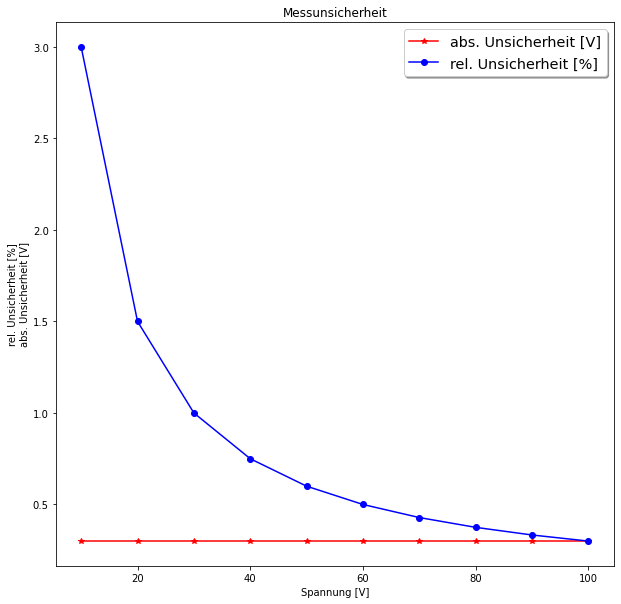

In [3]:
# Aufgabe 1.2

# geg:

GK     = 0.3
MB     = 100
U_min  = 10
U_max  = 100
U_step = 10

# Loesung:

U      = np.arange(U_min, U_max + U_step, U_step)
e_abs  = (MB * GK / 100) * np.ones(len(U))
e_rel  = e_abs / U * 100

# Ausgabe

fig, ax = plt.subplots()
ax.plot(U, e_abs, "*-", color = "red", label="abs. Unsicherheit [V]")
ax.plot(U, e_rel, "o-", color = "blue", label="rel. Unsicherheit [%]")
ax.set_title("Messunsicherheit")
ax.set_xlabel("Spannung [V]")
ax.set_ylabel("rel. Unsicherheit [%]\nabs. Unsicherheit [V]")

legend = ax.legend(loc='upper right', shadow=True, fontsize='x-large')

plt.show()

## 2) Statische Kennlinie

Der Zusammenhang zwischen der Messgröße $x$ und dem Messwert $y$ wird durch die **Kennlinie** $y = k(x)$ dargestellt.

### 2.1) Lineare Kennlinie

Lineare Kennlinien lassen sich durch den Kennlinienanstieg (auch Empfindlichekeit oder Gain) $K = \frac{\Delta y}{\Delta x}$ und den Nullpunktversatz (auch Offset) $y_0$ wie folgt darstellen.

$$y = k(x) = K \cdot x + y_0$$

Die folgende Abbildung zeigt die Ausgangssignale unterschiedlicher linearer Kennlinien bei gleichbleibendem sinusförmigen Eigangssignal.

![250515_seminar1imgLineareKennlinie.png](250515_seminar1imgLineareKennlinie.png "Lineare Kennlinie")

### 2.2) Nichtlinieare Kennlinien

Im Gegensatz zu linearen Kennlinien, kann es bei nichtlinearen Kennlinien keinen allgemeingültigen mathematischen Zusammenhang für den Zusammenhang zwischen $x$ und $y$ geben. Um mit nichtliniearen Kennlinien arbeiten zu können, gibt es verschiedene Verfahrensweisen. Exemplarisch seien genannt:

 + Vergleichstabellen (auch Wertetabellen oder Look-Up-Tables (LUT) genannt)
 + Anwendung der Umkehrfunktion (falls die Kennlinie einer bekannten, invertierbaren Funktion entpspricht)
 + Linearisierung im Arbeitspunkt
 + Interpolation um den Arbeitspunkt

Die im Arbeitspunkt **linearisierte Kennlinie** $\tilde{k}(x)$ kann wie folgt bestimmt werden.

$$ y \approx \tilde{k}(x) = \frac{d}{dx}k(x)\Bigr\rvert_{x_{AP}}$$
$$ \tilde{k}(x) = \frac{d}{dx_{AP}} k(x_{AP}) \cdot (x - x_{AP}) + k(x_{AP})$$

In der folgenden Abbildung werden zwei Sinussignale (mit großer und kleiner Auslenkung um den Arbeitspunkt) einer nichtlinearen Kennlinie und der dazugehörigen (im Arbeitspunkt) linearisierten Kennlinie zugeführt. Zum einen ist die Verzerrung des Ausgangssignals im Verhältnis zum Eingangssignal durch die nichtlineare Kennlinie zu erkennen. Zum anderen ist zu erkennen, wie sich die Abweichung zwischen die beiden Ausgangssignalen entwickelt, wenn sich das Eingangssignal vom Arbeitspunkt entfernt.

![250515_seminar1imgNichtlineareKennlinie.png](250515_seminar1imgNichtlineareKennlinie.png "Nichtlineare Kennlinie")

# 2.3) Aufgabe

Sie haben einen NTC10K-Widerstandstemperaturfühler, dem sie zur Messung einer Raumtemperatur verwenden möchten. Dessen nichtlineare Kennlinie lässt ich im Bereich $10\degree\text{C}...30\degree\text{C}$ durch folgende quadratische Funktion annähern.
$$R = k(\rho) = 14,82 \frac{\Omega}{\degree\text{C}^2} \cdot \rho^2 - 1185 \cdot \frac{\Omega}{\degree\text{C}} \cdot \rho + 30284 \Omega$$

 + Lineariesieren Sie diese Kennlinie im Arbeitspunkt $20\degree\text{C}$.
 + Plotten Sie $k(x)$ und $\tilde{k}(x)$ im Bereich $0...40\degree\text{C}$.
 + Ermitteln Sie die betragsmäßig maximale Abweichung zwischen der quadratischen und linearisierten Funktion im Bereich zwischen $10\degree\text{C}...30\degree\text{C}$ sowie im Bereich zwischen $0\degree\text{C}...40\degree\text{C}$.

*Randbemerkung NTC10k:*
 + *Halbleiterbasierter Widerstandstemperaturfühler*
 + *Der qualitative Kennlinienverlauf entspricht etwa der Funktion $\frac{1}{x}$*
 + *NTC > Negative Temperature Coefficent > mit steigender Temperatur sinkt der Widerstand > dt. Bez.: Heißleiter (Halbleiter sind i.d.R NTCs, Metalle sind PTCs > Kaltleiter)*


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

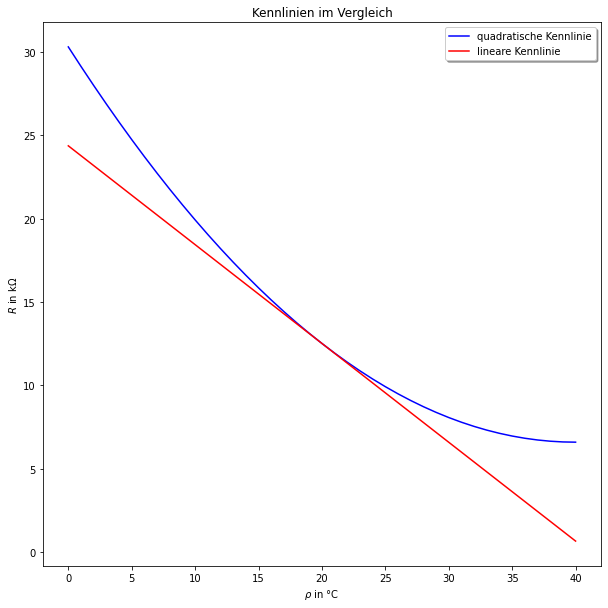

In [4]:
#Aufgabe 2.3

# geg:

# quadratisch interpolierte Kennlinie des NTC10k: fct_k(x)

a = 14.82
b = -1185
c = 30284

def fct_k(x):
  gain1  = a
  gain2  = b
  offset = c

  return gain1 * x**2 + gain2 * x + offset

# Temperaturbereiche 10...30 und 0...40 degCelsius

rho10_30 = np.arange(10, 31, 1)
rho00_40 = np.arange( 0, 41, 1)

# Loesung: ######################################

# Anwendung der Linearisierung im AP

display(Latex(r"$\tilde{k}(x) = \frac{d}{dx_{AP}} k(x_{AP}) \cdot (x - x_{AP}) + k(x_{AP})$"))
display(Latex(r"$\tilde{k}(x) = \frac{d}{dx_{AP}} (a \, x_{AP}^2 + b \, x_{AP} + c) \cdot (x - x_{AP}) + k(x_{AP})$"))
display(Latex(r"$\tilde{k}(x) = (2 \, a \, x_{AP} + b) \cdot (x - x_{AP}) + k(x_{AP}) = K \cdot (x - x_{AP}) + y_0$"))
display(Latex(r"$\tilde{k}(x) = (2 \, a \, x_{AP} + b) \cdot (x - x_{AP}) + k(x_{AP}) + y_0$"))
display(Latex(r"$K = (2 \, a \, x_{AP} + b) \hspace{2cm} y_0 = k(x_{AP})$"))

# Erstellen der linearen Kennlinie

def fct_kTilde(x):
  xAp    = 20
  K   = 2 * a * xAp + b
  y0  = fct_k(xAp)

  return K * (x - xAp) + y0

# Uebergabe der Plot-Daten

xPlot  = rho00_40
y1Plot = fct_k(rho00_40)
y2Plot = fct_kTilde(rho00_40)

# Ermitteln der absoluten / relativen Abweichungen an den Enden der zu untersuchenden Bereiche

eAbsMax10_30 = np.max(np.abs(fct_kTilde(rho10_30) - fct_k(rho10_30)))
eRelMax10_30 = np.max(np.abs(fct_kTilde(rho10_30) / fct_k(rho10_30) - 1))
eAbsMax00_40 = np.max(np.abs(fct_kTilde(rho00_40) - fct_k(rho00_40)))
eRelMax00_40 = np.max(np.abs(fct_kTilde(rho00_40) / fct_k(rho00_40) - 1))

# ###############################################

# Ausgabe:

fig, ax = plt.subplots()
ax.plot(xPlot, y1Plot / 1000, color="blue", label="quadratische Kennlinie")
ax.plot(xPlot, y2Plot / 1000, color="red", label="lineare Kennlinie")
ax.set_title("Kennlinien im Vergleich")
ax.set_xlabel("$\\rho$ in $\degree$C")
ax.set_ylabel("$R$ in k$\Omega$")
ax.legend(loc='upper right', shadow=True)

eAbsMax10_30 = np.round(eAbsMax10_30 * 1E3) / 1E3
eRelMax10_30 = np.round(eRelMax10_30 * 1E3) / 1E3
eAbsMax00_40 = np.round(eAbsMax00_40 * 1E3) / 1E3
eRelMax00_40 = np.round(eRelMax00_40 * 1E3) / 1E3

display(Latex(r"Die maximalen absoluten und relativen Abweichungen betragen:"))

display(Latex(r"$e_{abs, max}(\rho = 10\degree\text{C}...30\degree\text{C}) =" + latex(eAbsMax10_30) + "\,\\text{k}\Omega$"))
display(Latex(r"$e_{rel, max}(\rho = 10\degree\text{C}...30\degree\text{C}) =" + latex(eRelMax10_30 * 100) + "\,\\%$"))
display(Latex(r"$e_{abs, max}(\rho =  0\degree\text{C}...40\degree\text{C}) =" + latex(eAbsMax00_40) + "\,\\text{k}\Omega$"))
display(Latex(r"$e_{rel, max}(\rho =  0\degree\text{C}...40\degree\text{C}) =" + latex(eRelMax00_40 * 100) + "\,\\%$"))





## 3) Dynamische Eigenschaften von Messsystemen

Das Verhalten von Messsystem ist in der Realität immer von der zeitlichen Veränderung des Messsignals abhängig. Sie können nicht beliebig schnell auf Änderungen reagieren. In der Regel besteht kein Problem, wenn die Frequenz der Messgröße $w_x$ um Größenordnungen kleiner ist als die Eigenfrequenz des Messsystems $\omega_0$. Man spricht dann von einer quasistatischen Messung.

$$ G(\omega) = \frac{U_a(\omega)}{U_e(\omega)} = \frac{X_C}{R + X_C} $$
$$ G(\omega) = \frac{1}{R\omega C \cdot j + 1} $$
$$ |G(\omega)| = \frac{1}{\sqrt{R^2\omega^2C^2 + 1}} $$
$$ \varphi(\omega) = \arctan(\{4})$$

ax[0].set_xscale("log")

### 3.1) Aufgabe

Es wird der Widerstandswert eines Dehnungsmessstreifen (DMS) mit einem Trägerfrequenzmessverstärker gemessen. Dadurch lässt sich der Einfluss äußerer elektromagnetischer Störungen herausrechenen.

Sie sehen, dass der Widerstand sich signifikant erhöht hat, obwohl das unrealisitisch erscheint

Sie ändern die Frequenz, bei gleichbleibendenem Messwert

Sie errechenen L

Sie rehcenen L raus

Zeichne Sie die Ortskurve

# Notizen zu aus dem zweiten Teil von VL 1

## RLC-Glied

### Übertragungsfunktion

$$ \underline{G}(\omega)
  = \frac{\underline{U_a}}{\underline{U_e}}
  = \frac{\frac{1}{j\omega C}}{R + j(\omega L - \frac{1}{\omega C})})
  = \frac{1}{j\omega RC - wc (\omega L - \frac{1}{\omega C})}
  = \underline{\frac{1}{1 - \omega^2CL + j\omega RC}}
$$

### Amplitudengang

$$
  |G(\omega)| = \frac{1}{\sqrt{(1 - \omega^2CL)^2 + (\omega RC)^2}}
$$

### Phasengang

$$
  \varphi_G(\omega) = -\arctan(\frac{\omega RC}{1 - \omega^2CL})
$$

**Info: Warum -atan?:** man bildet G^-1 >> sucht Phi >> Es gilt Phi_G^-1 = -Phi_G

## Grenzfrequenz

Die Grenzfrequenz ist jene Frequenz, bei dem die Signalamplitude um einen definierten Faktor gedämpft wird. Im Allgemeinen wird als Faktor $\frac{1}{\sqrt{2}}$ verwendet.

$$ -3 dB = 20 * lg(\frac{y}{x}) $$
$$ \frac{-3}{20} = lg(\frac{y}{x}) $$
$$ 10^{\frac{-3}{20}} = \frac{y}{x} = 0,7079 \approx \frac{1}{\sqrt{2}} $$

**INFO:** In $T_1$-Systemen beträgt die Phasenverschiebung bei der Grenzfrequenz genau $45\degree$.

## Bandbreite

Die 3dB Bandbreite $B_{3\text{dB}}$ ist der Frequenzbereich, bei dem die Bedingung der Grenzfrequenz nicht verletzt wird.

## Impulsantwort

Wird einem System ein Dirac-Impuls $\delta(t)$ am Eingang zugeführt (unendlich kurz, unendlich hoch, Fläche 1), so gibt das System am Ausgang die Impulsantwort $g(t)$ aus. Die Impulsantwort enthält alle Informationen zum System.

Durch Fouriertransformation lässt sich die Impulsantwort in die Übertragungsfunktion überführen und invers.

$$\underline{G}(\omega) = \int_{-\infty}^{\infty}(g(t)\exp(-j\omega t))dt = \mathcal{F}(g(t))$$
$$g(t) = \int_{-\infty}^{\infty}(\underline{G}(\omega)\exp(j\omega t))d\omega = \mathcal{F}^{-1}(\underline{G}(\omega))$$

## Sprungantwort

Wird einem System ein Dirac-Impuls $\sigma(t)$ am Eingang zugeführt (unendlich kurz, unendlich hoch, Fläche 1), so gibt das System am Ausgang die Impulsantwort $h(t)$ aus. Die Impulsantwort enthält alle Informationen zum System.

Die Impulsantwort ergibt sich aus der Ableitung der Sprungantwort.

$$g(t) = \frac{d}{dt}(h(t))$$

## Einschwingzeit

Gibt die Zeit an, die das Messsystem benötigt, um das Messsignal zu einen definierten Anteil zu erfassen.

Übliche Toleranzbänder sind: $\pm 1\%$, $\pm 5\%$, $\pm 10\%$, $\pm(1 - \frac{1}{\sqrt{2}}) \cdot 100\% = 63,2\%$

Bei $T_1$ System kann die Zeitkonstante als vielfache der Zeitkonstante $\tau$ angegeben werden.

$$
  (1 - \frac{1}{e})
$$

aus

$$
  y(t) = 1 - e^{-\frac{t}{\tau}}
$$

Für $T_2^*$ gilt, dass die Einschwingzeit der Zeitpunkt ist, wo das Einschwingen sich nicht mehr aus dem Toleranzbereich herausbewegt!

## Zusammenhang zwischen Einschwingzeit und grenzfrequenz bei $T_1$-Systemen

Wenn für $T_{Einschwing}$ die $63,2 \%$ Toleranzgrenze gilt und für $f_g$ die $\frac{1}{\sqrt{2}}$ gilt, dann...

$$
  \underline{G}(\omega) = \frac{1}{1 + j\omega RC} = \frac{1}{1 + j\omega\tau}
$$

Amplitudengang:

$$
  |\underline{G}(\omega)| = \frac{1}{\sqrt{1 + j\omega^2\tau^2}}
$$

$$
  \frac{1}{\sqrt{2}} = \frac{1}{\sqrt{1 + \omega_g^2\tau^2}} | (\cdot)^{-1} | (\cdot)^2
$$

$$
  2 = 1 + \omega_g^2\tau^2
$$

$$
  1 = \omega_g^2\tau^2
$$

$$
 \omega_g = \frac{1}{\tau}
$$

$$
  f_g = \frac{1}{2\pi\tau}
$$




Jetzt macht die $\frac{1}{\sqrt{2}}$-Definition auch Sinn.


In [ ]:
R = 7
C = 47 * 1e-6
L = 1e-2

tau = 47 * 1e-4

D = R / 2 * np.sqrt(C/L)
print(f"{D=}")

dt = tau * 1e-2
t = np.arange(0, 10 * tau, dt)
w0 = 1 / npsqrt(L * C)
w = np.linspace(0, 10 * w0, 1e3)
f = w / 2 / np.pi

G = 1 / (1 - w**2 * L * C + 1j * w * R * C)

D=0.23994791101403654


AttributeError: module 'numpy' has no attribute 'arang'